#### 1. Random Forest
#### 2. SVM
#### 3. Logistic Regression
#### 4. Naive Bayes

In [1]:
#1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
#Import data
heart_disease = pd.read_csv("heart.csv")
heart_disease.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
#data preprocessing
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in heart_disease.columns:
    if heart_disease[col].dtype=='object':
        heart_disease[col]=le.fit_transform(heart_disease[col])

In [3]:
#create X (features matrix)
x = heart_disease.drop("HeartDisease", axis = 1)
#create Y (labels)
y = heart_disease["HeartDisease"] 
x

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,1,1,140,289,0,1,172,0,0.0,2
1,49,0,2,160,180,0,1,156,0,1.0,1
2,37,1,1,130,283,0,2,98,0,0.0,2
3,48,0,0,138,214,0,1,108,1,1.5,1
4,54,1,2,150,195,0,1,122,0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,3,110,264,0,1,132,0,1.2,1
914,68,1,0,144,193,1,1,141,0,3.4,1
915,57,1,0,130,131,0,1,115,1,1.2,1
916,57,0,1,130,236,0,0,174,0,0.0,1


In [4]:
#split the dataset into train test sets
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

### Random Forest

5 fold Cross Validation Accuracy: 85.28%

5 fold Cross Validation Precision: 0.8547661505296948

5 fold Cross Validation Recall: 0.8814117647058822

5 fold Cross Validation F1 Score: 0.8691316049114395



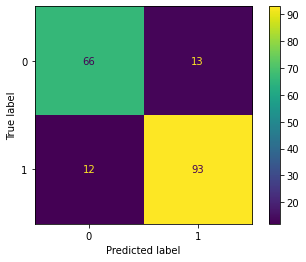

In [5]:
from sklearn.ensemble import RandomForestClassifier

#np.random.seed(100)


params = {'n_estimators': 200,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 40,
 'bootstrap': True}



#instantiate the object 
rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=1, min_samples_split=10,max_features="sqrt", max_depth=40, bootstrap="True")

#fit the model with train sets
rf.fit(x_train, y_train)

#prediction
y_pred_rf = rf.predict(x_test) 

#======Evaluation=====================
#print(f"Test Accuracy: {rf.score(x_test, y_test)}\n")
#print(rf.score(x_test, y_test))

#Confusion Matrix
#print(confusion_matrix(y_test, y_pred_rf))
#ConfusionMatrixDisplay.from_estimator(estimator = rf, X =x, y = y)
ConfusionMatrixDisplay.from_predictions(y_true = y_test, y_pred = y_pred_rf)

#Five fold CV accuracy
rf_cv_acc = np.mean(cross_val_score(rf, x, y, cv = 10, scoring = "accuracy")) #scoring = none will use the default score(x_test, y_test) for each set
print(f"5 fold Cross Validation Accuracy: {rf_cv_acc * 100:.2f}%\n")

#Five fold CV precision
rf_cv_pre = np.mean(cross_val_score(rf, x, y, cv = 10, scoring = "precision"))
print(f"5 fold Cross Validation Precision: {rf_cv_pre}\n")

#Five fold CV recall
rf_cv_recall = np.mean(cross_val_score(rf, x, y, cv = 10, scoring = "recall"))
print(f"5 fold Cross Validation Recall: {rf_cv_recall}\n")

#Five fold CV F1
rf_cv_f1 = np.mean(cross_val_score(rf, x, y, cv = 10, scoring = "f1"))
print(f"5 fold Cross Validation F1 Score: {rf_cv_f1}\n")

#ROC: Comparison between models TP and FP

#Classification report
#print(classification_report(y_test, y_pred_rf))

#Tuning Hyperparameters using RandomSearchCV, GridSearchCV

### RandomSearchCV for Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier
grid = {'bootstrap': [True, False],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
 'max_features': ['sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}


#Setup RandomSearchCV
rf_2 = RandomizedSearchCV(estimator = RandomForestClassifier(),
                           param_distributions=grid,
                           n_iter=10,
                           cv=10,
                           verbose=2)
#Fit the RandomizedSearhCV version 
rf_2.fit(x_train, y_train)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV] END bootstrap=False, max_depth=70, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=   1.2s
[CV] END bootstrap=False, max_depth=70, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=   1.1s
[CV] END bootstrap=False, max_depth=70, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=   1.1s
[CV] END bootstrap=False, max_depth=70, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=   1.1s
[CV] END bootstrap=False, max_depth=70, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=   1.1s
[CV] END bootstrap=False, max_depth=70, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=1000; total time=   1.1s
[CV] END bootstrap=False, max_depth=70, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimat

[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=2000; total time=   2.4s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1800; total time=   2.0s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1800; total time=   2.0s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1800; total time=   1.9s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1800; total time=   2.0s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1800; total time=   2.2s
[CV] END bootstrap=False, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1800; total time=   2.3s
[CV] END bootstrap=Fals

RandomizedSearchCV(cv=10, estimator=RandomForestClassifier(),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   verbose=2)

In [10]:
#Show the best parameter from RandomSearchCV for Random forest
rf_2.best_params_

{'n_estimators': 1800,
 'min_samples_split': 5,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': None,
 'bootstrap': False}

              precision    recall  f1-score   support

           0       0.83      0.82      0.83        79
           1       0.87      0.88      0.87       105

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



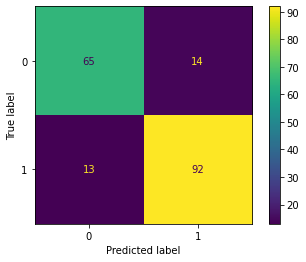

In [14]:
#Make predictions with the best hyperparameters
y_pred_rf_2 = rf_2.predict(x_test)
#Evaluate the predictions
rf_2.score(x_test, y_test)
print(classification_report(y_test, y_pred_rf_2))

#Five fold CV accuracy
#rf_2_cv_acc = np.mean(cross_val_score(rf_2, x, y, cv = 5, scoring = "accuracy")) #scoring = none will use the default score(x_test, y_test) for each set
#print(f"5 fold Cross Validation Accuracy: {rf_2_cv_acc * 100:.2f}%\n")
ConfusionMatrixDisplay.from_predictions(y_true = y_test, y_pred = y_pred_rf_2)

In [30]:
#Five fold CV precision
rf_2_cv_pre = np.mean(cross_val_score(rf_2, x, y, cv = 5, scoring = "precision"))
print(f"5 fold Cross Validation Precision: {rf_2_cv_pre}\n")

#Five fold CV recall
rf_2_cv_recall = np.mean(cross_val_score(rf_2, x, y, cv = 5, scoring = "recall"))
print(f"5 fold Cross Validation Recall: {rf_2_cv_recall}\n")

#Five fold CV F1
rf_2_cv_f1 = np.mean(cross_val_score(rf_2, x, y, cv = 5, scoring = "f1"))
print(f"5 fold Cross Validation F1 Score: {rf_2_cv_f1}\n")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=False, max_depth=80, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1600; total time=   1.7s
[CV] END bootstrap=False, max_depth=80, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1600; total time=   1.7s
[CV] END bootstrap=False, max_depth=80, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1600; total time=   1.6s
[CV] END bootstrap=False, max_depth=80, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1600; total time=   1.6s
[CV] END bootstrap=False, max_depth=80, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1600; total time=   1.6s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   0.4s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimat

[CV] END bootstrap=False, max_depth=80, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1800; total time=   1.9s
[CV] END bootstrap=True, max_depth=90, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.2s
[CV] END bootstrap=True, max_depth=90, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.2s
[CV] END bootstrap=True, max_depth=90, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.2s
[CV] END bootstrap=True, max_depth=90, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.2s
[CV] END bootstrap=True, max_depth=90, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.2s
[CV] END bootstrap=False, max_depth=90, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=1000; total time=   1.0s
[CV] END bootstrap=False, max_depth=90, max_

[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=1200; total time=   1.4s
[CV] END bootstrap=False, max_depth=60, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1400; total time=   1.4s
[CV] END bootstrap=False, max_depth=60, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1400; total time=   1.5s
[CV] END bootstrap=False, max_depth=60, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1400; total time=   1.6s
[CV] END bootstrap=False, max_depth=60, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1400; total time=   1.5s
[CV] END bootstrap=False, max_depth=60, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1400; total time=   1.4s
[CV] END bootstrap=True, max_depth=70, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=400; total time=   0.4s
[CV] END bootstrap=True, max_depth=70

KeyboardInterrupt: 

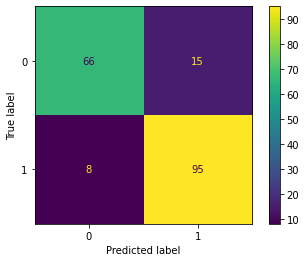

In [9]:
ConfusionMatrixDisplay.from_predictions(y_true = y_test, y_pred = y_pred_rf_2)

### Linear SVM

10 fold Cross Validation Accuracy: 83.32%

10 fold Cross Validation Precision: 0.8527347009576367

10 fold Cross Validation Recall: 0.8499607843137256

10 fold Cross Validation F1 Score: 0.8473960356173



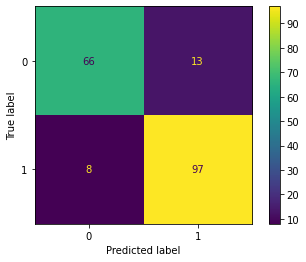

In [6]:
from sklearn.svm import SVC 

np.random.seed(100)

#instantiate the object 
svc = SVC(kernel = 'linear')

#fit the model with train sets
svc.fit(x_train, y_train)

#prediction
y_pred_svc = svc.predict(x_test) 

#======Evaluation=====================

#svc.score(x_test, y_test)
#print(classification_report(y_test, y_pred_svc))
#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_true = y_test, y_pred = y_pred_svc)

#Five fold CV accuracy
svc_cv_acc = np.mean(cross_val_score(svc, x, y, cv = 10, scoring = "accuracy")) #scoring = none will use the default score(x_test, y_test) for each set
print(f"10 fold Cross Validation Accuracy: {svc_cv_acc * 100:.2f}%\n")

#Five fold CV precision
svc_cv_pre = np.mean(cross_val_score(svc, x, y, cv = 10, scoring = "precision"))
print(f"10 fold Cross Validation Precision: {svc_cv_pre}\n")

#Five fold CV recall
svc_cv_recall = np.mean(cross_val_score(svc, x, y, cv = 10, scoring = "recall"))
print(f"10 fold Cross Validation Recall: {svc_cv_recall}\n")

#Five fold CV F1
svc_cv_f1 = np.mean(cross_val_score(svc, x, y, cv = 10, scoring = "f1"))
print(f"10 fold Cross Validation F1 Score: {svc_cv_f1}\n")


### Logistic Regression

              precision    recall  f1-score   support

           0       0.89      0.82      0.86        79
           1       0.87      0.92      0.90       105

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.88       184
weighted avg       0.88      0.88      0.88       184

10 fold Cross Validation Accuracy: 82.99%

10 fold Cross Validation Precision: 0.854582140114921

10 fold Cross Validation Recall: 0.8421176470588236

10 fold Cross Validation F1 Score: 0.8435214719801186



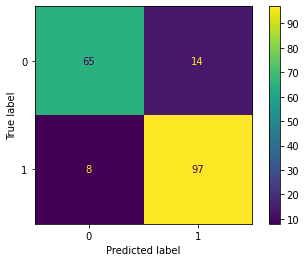

In [12]:
from sklearn.linear_model import LogisticRegression

#np.random.seed(100)

#instantiate the object 
lreg = LogisticRegression(random_state=0, max_iter = 1000)

#fit the model with train sets
lreg.fit(x_train, y_train)

#prediction
y_pred_lreg = lreg.predict(x_test) 

#======Evaluation=====================

lreg.score(x_test, y_test)
print(classification_report(y_test, y_pred_lreg))

#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_true = y_test, y_pred = y_pred_lreg)


#Five fold CV accuracy
lreg_cv_acc = np.mean(cross_val_score(lreg, x, y, cv = 10, scoring = "accuracy")) #scoring = none will use the default score(x_test, y_test) for each set
print(f"10 fold Cross Validation Accuracy: {lreg_cv_acc * 100:.2f}%\n")

#Five fold CV precision
lreg_cv_pre = np.mean(cross_val_score(lreg, x, y, cv = 10, scoring = "precision"))
print(f"10 fold Cross Validation Precision: {lreg_cv_pre}\n")

#Five fold CV recall
lreg_cv_recall = np.mean(cross_val_score(lreg, x, y, cv = 10, scoring = "recall"))
print(f"10 fold Cross Validation Recall: {lreg_cv_recall}\n")

#Five fold CV F1
lreg_cv_f1 = np.mean(cross_val_score(lreg, x, y, cv = 10, scoring = "f1"))
print(f"10 fold Cross Validation F1 Score: {lreg_cv_f1}\n")





### Naive Bayes

10 fold Cross Validation Accuracy: 84.52%

10 fold Cross Validation Precision: 0.8741475514026902

10 fold Cross Validation Recall: 0.8576862745098038

10 fold Cross Validation F1 Score: 0.8565532270568926



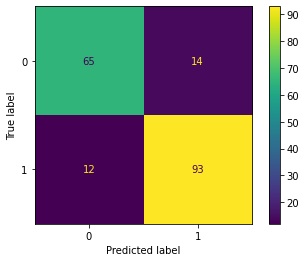

In [8]:
from sklearn.naive_bayes import GaussianNB

np.random.seed(100)

#instantiate the object 
nb = GaussianNB()

#fit the model with train sets
nb.fit(x_train, y_train)

#prediction
y_pred_nb = nb.predict(x_test) 

#======Evaluation=====================

#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_true = y_test, y_pred = y_pred_nb)

#Five fold CV accuracy
nb_cv_acc = np.mean(cross_val_score(nb, x, y, cv = 10, scoring = "accuracy")) #scoring = none will use the default score(x_test, y_test) for each set
print(f"10 fold Cross Validation Accuracy: {nb_cv_acc * 100:.2f}%\n")

#Five fold CV precision
nb_cv_pre = np.mean(cross_val_score(nb, x, y, cv = 10, scoring = "precision"))
print(f"10 fold Cross Validation Precision: {nb_cv_pre}\n")

#Five fold CV recall
nb_cv_recall = np.mean(cross_val_score(nb, x, y, cv = 10, scoring = "recall"))
print(f"10 fold Cross Validation Recall: {nb_cv_recall}\n")

#Five fold CV F1
nb_cv_f1 = np.mean(cross_val_score(nb, x, y, cv = 10, scoring = "f1"))
print(f"10 fold Cross Validation F1 Score: {nb_cv_f1}\n")


In [13]:
heart_disease.isna().sum().sum()

0

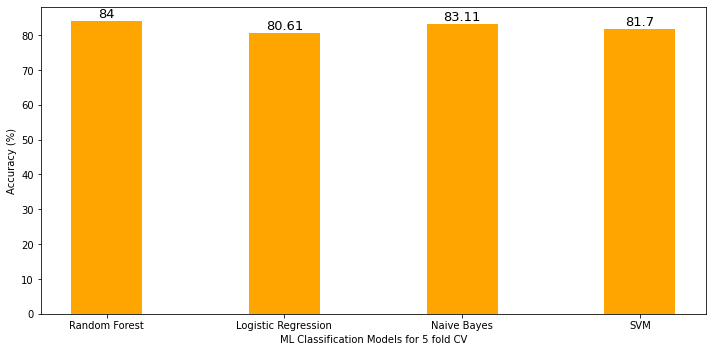

In [70]:
# creating the dataset
data = {'Random Forest':84, 'Logistic Regression':80.61, 'Naive Bayes':83.11,
        'SVM':81.70}
models = list(data.keys())
accuracy = list(data.values())
  
fig = plt.figure(figsize = (10, 5))
 
# creating the bar plot
plt.bar(models, accuracy, color ='orange',
        width = 0.4)
 
plt.xlabel("ML Classification Models for 5 fold CV")
plt.ylabel("Accuracy (%)")
for index,data in enumerate(accuracy):
    plt.text(x=index , y =data+1 , s=f"{data}" , fontdict=dict(fontsize=13), ha='center')
plt.tight_layout()
#plt.title("Students enrolled in different courses")
plt.show()

             ML Models  TP  FP  TN  FN
0        Random Forest  70  12  91  11
1  Logistic Regression  62  10  96  16
2          Naive Bayes  62  12  94  16
3                  SVM  64  17  91  13


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Random Forest'),
  Text(1, 0, 'Logistic Regression'),
  Text(2, 0, 'Naive Bayes'),
  Text(3, 0, 'SVM')])

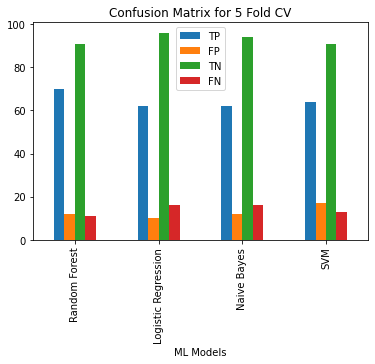

In [77]:
# create data
df = pd.DataFrame([['Random Forest', 70, 12, 91, 11], ['Logistic Regression', 62, 10, 96, 16], ['Naive Bayes', 62, 12, 94, 16],
                   ['SVM', 64, 17, 91, 13]],
                  columns=['ML Models', 'TP', 'FP', 'TN', 'FN'])
# view data
print(df)
 
# plot grouped bar chart
#fig = plt.figure(figsize = (10, 5)) 
df.plot(x='ML Models',
        kind='bar',
        stacked=False,
        title='Confusion Matrix for 5 Fold CV')


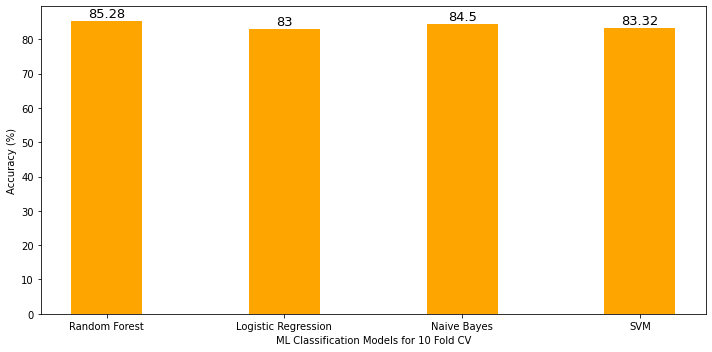

In [72]:
#bar plot for 10 cv

data = {'Random Forest':85.28, 'Logistic Regression':83, 'Naive Bayes':84.50,
        'SVM':83.32}
models = list(data.keys())
accuracy = list(data.values())
  
fig = plt.figure(figsize = (10, 5))
 
# creating the bar plot
plt.bar(models, accuracy, color ='orange',
        width = 0.4)
 
plt.xlabel("ML Classification Models for 10 Fold CV")
plt.ylabel("Accuracy (%)")
for index,data in enumerate(accuracy):
    plt.text(x=index , y =data+1 , s=f"{data}" , fontdict=dict(fontsize=13), ha='center')
plt.tight_layout()
#plt.title("Students enrolled in different courses")
plt.show()


             ML Models  TP  FP  TN  FN
0        Random Forest  66  12  93  13
1  Logistic Regression  65   8  97  14
2          Naive Bayes  65  12  93  14
3                  SVM  66   8  97  13


<AxesSubplot:title={'center':'Confusion Matrix for 10 Fold CV'}, xlabel='ML Models'>

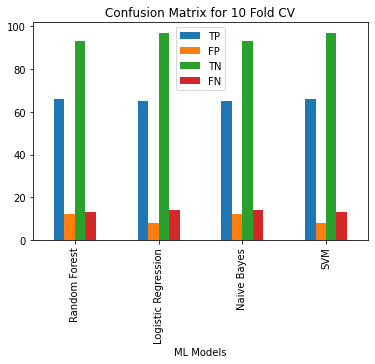

In [74]:
#Bar plot for 10cv confusion matrix
# create data
df = pd.DataFrame([['Random Forest', 66, 12, 93, 13], ['Logistic Regression', 65, 8, 97, 14], ['Naive Bayes', 65, 12, 93, 14],
                   ['SVM', 66, 8, 97, 13]],
                  columns=['ML Models', 'TP', 'FP', 'TN', 'FN'])
# view data
print(df)
 
# plot grouped bar chart
#fig = plt.figure(figsize = (10, 5)) 
df.plot(x='ML Models',
        kind='bar',
        stacked=False,
        title='Confusion Matrix for 10 Fold CV')